# Intersection Traffic Flow Simulation Under Multiple Demand Scenarios

## 1. Title and Objective

This notebook develops a scenario-based simulation environment for a simplified two-phase signalized intersection. Building on the earlier forecasting, external-factor integration, baseline timing, and optimization formulation notebooks, it compares how a fixed-time baseline strategy and a demand-responsive optimized timing strategy perform under multiple traffic demand conditions.

The purpose is not to solve a full mathematical optimization model in this notebook. Instead, the notebook provides a clean analytical simulation framework that estimates comparative operational outcomes such as delay, throughput, queue pressure, and demand served per cycle. This makes the notebook suitable for evaluating when signal timing adaptation is most beneficial and for supporting later optimization impact assessment.


## 2. Simulation Overview

The simulation in this notebook is **analytical rather than microscopic**. It does not model individual vehicles, lane-changing behavior, or stochastic car-following processes. Instead, it estimates proxy intersection performance by combining traffic demand, green allocation, and saturation flow assumptions in a simplified two-phase setting.

This structure is appropriate for the capstone because it supports transparent and reproducible comparison across scenarios. The main goal is to evaluate how baseline and optimized signal timing strategies respond when traffic demand shifts from lighter off-peak conditions to heavier peak-period pressure.


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

repo_root = Path.cwd()
if not (repo_root / "data").exists() and repo_root.parent.exists():
    repo_root = repo_root.parent

processed_dir = repo_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

results_output_path = processed_dir / "intersection_simulation_results.csv"
summary_output_path = processed_dir / "intersection_simulation_summary.csv"
enhanced_results_output_path = processed_dir / "intersection_simulation_results_enhanced.csv"

pd.options.display.float_format = "{:,.2f}".format


## 3. Define Traffic Flow Scenarios

Three traffic demand scenarios are used to reflect plausible variation in intersection loading:

- **Off-Peak Demand** represents lighter traffic conditions.
- **Normal Demand** represents the reference planning condition.
- **Peak Demand** represents materially heavier demand pressure.

These scenarios were selected because they provide a simple but interpretable stress test of timing strategies. They are also consistent with the wider capstone workflow, where traffic forecasting and external factors motivate the need to evaluate signal performance under changing demand intensity rather than under a single static operating point.


In [9]:
cycle_length = 90
g_min = 15
saturation_flow = 1800

base_demand_phase1 = 800
base_demand_phase2 = 500

scenarios = {
    "Off-Peak Demand": 0.6,
    "Normal Demand": 1.0,
    "Peak Demand": 1.4,
}
scenario_order = ["Off-Peak Demand", "Normal Demand", "Peak Demand"]
strategy_order = ["Baseline", "Optimized"]

scenario_df = pd.DataFrame(
    [
        {
            "scenario": name,
            "demand_multiplier": multiplier,
            "demand_phase1": base_demand_phase1 * multiplier,
            "demand_phase2": base_demand_phase2 * multiplier,
        }
        for name, multiplier in scenarios.items()
    ]
)
scenario_df["scenario"] = pd.Categorical(scenario_df["scenario"], categories=scenario_order, ordered=True)
scenario_df = scenario_df.sort_values("scenario").reset_index(drop=True)
scenario_df["total_demand"] = scenario_df["demand_phase1"] + scenario_df["demand_phase2"]

display(scenario_df)


,scenario,demand_multiplier,demand_phase1,demand_phase2,total_demand
0,Off-Peak Demand,0.60,480.00,300.00,780.00
1,Normal Demand,1.00,800.00,500.00,"1,300.00"
2,Peak Demand,1.40,"1,120.00",700.00,"1,820.00"


## 4. Define Signal Timing Strategies

Two timing strategies are compared in the simulation.

**Baseline strategy.** A fixed-time benchmark is used with equal green allocation across the two phases and a common cycle length of 90 seconds. This mirrors the role of the baseline plan in earlier notebooks: it is intentionally simple, transparent, and suitable as a reference case.

**Optimized strategy.** The comparison strategy applies a demand-proportional green allocation rule while keeping the same cycle length for fairness. This is best interpreted as a **heuristic implementation of the optimization logic** introduced in the previous formulation notebook, not as a full solver. A minimum green constraint of 15 seconds per phase is enforced to preserve realism.


In [10]:
def allocate_optimized_greens(demand_phase1, demand_phase2, cycle_length=90, minimum_green=15):
    total_demand = demand_phase1 + demand_phase2
    green_phase1 = cycle_length * (demand_phase1 / total_demand)
    green_phase2 = cycle_length * (demand_phase2 / total_demand)

    green_phase1 = max(green_phase1, minimum_green)
    green_phase2 = max(green_phase2, minimum_green)

    if green_phase1 + green_phase2 > cycle_length:
        if green_phase1 == minimum_green:
            green_phase2 = cycle_length - minimum_green
        elif green_phase2 == minimum_green:
            green_phase1 = cycle_length - minimum_green
        else:
            scale = cycle_length / (green_phase1 + green_phase2)
            green_phase1 *= scale
            green_phase2 *= scale

    return round(green_phase1, 2), round(green_phase2, 2)


timing_rows = []
for row in scenario_df.itertuples(index=False):
    timing_rows.append(
        {
            "scenario": row.scenario,
            "strategy": "Baseline",
            "cycle_length": cycle_length,
            "green_phase1": cycle_length / 2,
            "green_phase2": cycle_length / 2,
        }
    )

    optimized_g1, optimized_g2 = allocate_optimized_greens(
        row.demand_phase1,
        row.demand_phase2,
        cycle_length=cycle_length,
        minimum_green=g_min,
    )
    timing_rows.append(
        {
            "scenario": row.scenario,
            "strategy": "Optimized",
            "cycle_length": cycle_length,
            "green_phase1": optimized_g1,
            "green_phase2": optimized_g2,
        }
    )

timing_df = pd.DataFrame(timing_rows)
timing_df["scenario"] = pd.Categorical(timing_df["scenario"], categories=scenario_order, ordered=True)
timing_df["strategy"] = pd.Categorical(timing_df["strategy"], categories=strategy_order, ordered=True)
timing_df = timing_df.sort_values(["scenario", "strategy"]).reset_index(drop=True)
timing_df["green_share_phase1"] = timing_df["green_phase1"] / timing_df["cycle_length"]
timing_df["green_share_phase2"] = timing_df["green_phase2"] / timing_df["cycle_length"]

display(timing_df)


,scenario,strategy,cycle_length,green_phase1,green_phase2,green_share_phase1,green_share_phase2
0,Off-Peak Demand,Baseline,90,45.00,45.00,0.50,0.50
1,Off-Peak Demand,Optimized,90,55.38,34.62,0.62,0.38
2,Normal Demand,Baseline,90,45.00,45.00,0.50,0.50
3,Normal Demand,Optimized,90,55.38,34.62,0.62,0.38
4,Peak Demand,Baseline,90,45.00,45.00,0.50,0.50
5,Peak Demand,Optimized,90,55.38,34.62,0.62,0.38


## 5. Simulation Model and Assumptions

The simulation adopts a compact analytical representation of intersection performance. For each phase, capacity is estimated from the ratio of allocated green time to cycle length multiplied by a nominal saturation flow of 1,800 vehicles per hour of green. Throughput is then defined as the smaller of demand and capacity, while queue pressure reflects positive unmet demand.

Delay is estimated using a simplified **Webster-style uniform delay** expression, with an additional oversaturation penalty when demand exceeds available phase capacity. The resulting delay values should be interpreted as comparative analytical indicators rather than calibrated field delays. This keeps the notebook logically aligned with earlier capstone notebooks, where the emphasis has been transparent benchmarking and interpretable optimization logic.


In [11]:
assumptions_df = pd.DataFrame(
    [
        {"assumption": "Intersection structure", "value": "Two phases: North-South and East-West"},
        {"assumption": "Cycle length", "value": f"{cycle_length} sec"},
        {"assumption": "Minimum green per phase", "value": f"{g_min} sec"},
        {"assumption": "Saturation flow", "value": f"{saturation_flow} veh/hour of green"},
        {"assumption": "Delay formulation", "value": "Simplified Webster-style uniform delay with oversaturation penalty"},
        {"assumption": "Simulation scope", "value": "Analytical scenario comparison, not microscopic simulation"},
    ]
)
display(assumptions_df)


def webster_delay(volume, capacity, green, cycle):
    if capacity <= 0 or green <= 0 or cycle <= 0:
        return np.nan

    x = volume / capacity
    g_over_c = green / cycle
    capped_x = min(1.0, x)
    denominator = 1 - (capped_x * g_over_c)

    if denominator <= 0:
        return np.nan

    return (0.5 * cycle * (1 - g_over_c) ** 2) / denominator


def simulate_intersection(demand_phase1, demand_phase2, g1, g2, cycle_length, saturation_flow=1800):
    capacity_phase1 = saturation_flow * (g1 / cycle_length)
    capacity_phase2 = saturation_flow * (g2 / cycle_length)

    throughput_phase1 = min(demand_phase1, capacity_phase1)
    throughput_phase2 = min(demand_phase2, capacity_phase2)

    queue_phase1 = max(demand_phase1 - capacity_phase1, 0)
    queue_phase2 = max(demand_phase2 - capacity_phase2, 0)

    uniform_delay_phase1 = webster_delay(demand_phase1, capacity_phase1, g1, cycle_length)
    uniform_delay_phase2 = webster_delay(demand_phase2, capacity_phase2, g2, cycle_length)

    # Add a simple penalty when demand exceeds available capacity so peak stress is reflected.
    oversat_penalty_phase1 = cycle_length * max((demand_phase1 / capacity_phase1) - 1, 0)
    oversat_penalty_phase2 = cycle_length * max((demand_phase2 / capacity_phase2) - 1, 0)

    total_demand = demand_phase1 + demand_phase2
    weighted_delay = (
        demand_phase1 * (uniform_delay_phase1 + oversat_penalty_phase1)
        + demand_phase2 * (uniform_delay_phase2 + oversat_penalty_phase2)
    ) / total_demand

    total_throughput = throughput_phase1 + throughput_phase2
    total_queue_pressure = queue_phase1 + queue_phase2
    demand_served_per_cycle = total_throughput * (cycle_length / 3600)

    return {
        "delay": weighted_delay,
        "throughput": total_throughput,
        "queue_pressure": total_queue_pressure,
        "demand_served_per_cycle": demand_served_per_cycle,
        "capacity_phase1": capacity_phase1,
        "capacity_phase2": capacity_phase2,
        "throughput_phase1": throughput_phase1,
        "throughput_phase2": throughput_phase2,
        "queue_phase1": queue_phase1,
        "queue_phase2": queue_phase2,
    }


,assumption,value
0,Intersection structure,Two phases: North-South and East-West
1,Cycle length,90 sec
2,Minimum green per phase,15 sec
3,Saturation flow,1800 veh/hour of green
4,Delay formulation,Simplified Webster-style uniform delay with ov...
5,Simulation scope,"Analytical scenario comparison, not microscopi..."


## 6. Scenario Simulation Results

The simulation is now run for every combination of demand scenario and timing strategy. The resulting table reports the key inputs and comparative proxy metrics needed for later interpretation.


In [12]:
simulation_rows = []

for scenario_row in scenario_df.itertuples(index=False):
    scenario_timings = timing_df.loc[timing_df["scenario"] == scenario_row.scenario]
    for timing_row in scenario_timings.itertuples(index=False):
        metrics = simulate_intersection(
            demand_phase1=scenario_row.demand_phase1,
            demand_phase2=scenario_row.demand_phase2,
            g1=timing_row.green_phase1,
            g2=timing_row.green_phase2,
            cycle_length=timing_row.cycle_length,
            saturation_flow=saturation_flow,
        )

        simulation_rows.append(
            {
                "scenario": scenario_row.scenario,
                "strategy": timing_row.strategy,
                "demand_phase1": scenario_row.demand_phase1,
                "demand_phase2": scenario_row.demand_phase2,
                "cycle_length": timing_row.cycle_length,
                "green_phase1": timing_row.green_phase1,
                "green_phase2": timing_row.green_phase2,
                "delay": metrics["delay"],
                "throughput": metrics["throughput"],
                "queue_pressure": metrics["queue_pressure"],
                "demand_served_per_cycle": metrics["demand_served_per_cycle"],
                "capacity_phase1": metrics["capacity_phase1"],
                "capacity_phase2": metrics["capacity_phase2"],
                "throughput_phase1": metrics["throughput_phase1"],
                "throughput_phase2": metrics["throughput_phase2"],
                "queue_phase1": metrics["queue_phase1"],
                "queue_phase2": metrics["queue_phase2"],
            }
        )

results_df = pd.DataFrame(simulation_rows)
results_df["scenario"] = pd.Categorical(results_df["scenario"], categories=scenario_order, ordered=True)
results_df["strategy"] = pd.Categorical(results_df["strategy"], categories=strategy_order, ordered=True)
results_df["total_demand"] = results_df["demand_phase1"] + results_df["demand_phase2"]
results_df["queue_pressure_ratio"] = results_df["queue_pressure"] / results_df["total_demand"]
results_df = results_df.sort_values(["scenario", "strategy"]).reset_index(drop=True)

results_df.to_csv(results_output_path, index=False)
results_df.to_csv(enhanced_results_output_path, index=False)

display(results_df.round(3))
print(f"Saved simulation results to: {results_output_path.relative_to(repo_root)}")
print(f"Saved enhanced simulation results to: {enhanced_results_output_path.relative_to(repo_root)}")


,scenario,strategy,demand_phase1,demand_phase2,cycle_length,green_phase1,green_phase2,delay,throughput,queue_pressure,demand_served_per_cycle,capacity_phase1,capacity_phase2,throughput_phase1,throughput_phase2,queue_phase1,queue_phase2,total_demand,queue_pressure_ratio
0,Off-Peak Demand,Baseline,480.00,300.00,90,45.00,45.00,14.63,780.00,0.00,19.50,900.00,900.00,480.00,300.00,0.00,0.00,780.00,0.00
1,Off-Peak Demand,Optimized,480.00,300.00,90,55.38,34.62,13.45,780.00,0.00,19.50,"1,107.60",692.40,480.00,300.00,0.00,0.00,780.00,0.00
2,Normal Demand,Baseline,800.00,500.00,90,45.00,45.00,18.45,"1,300.00",0.00,32.50,900.00,900.00,800.00,500.00,0.00,0.00,"1,300.00",0.00
3,Normal Demand,Optimized,800.00,500.00,90,55.38,34.62,16.45,"1,300.00",0.00,32.50,"1,107.60",692.40,800.00,500.00,0.00,0.00,"1,300.00",0.00
4,Peak Demand,Baseline,"1,120.00",700.00,90,45.00,45.00,34.47,"1,600.00",220.00,40.00,900.00,900.00,900.00,700.00,220.00,0.00,"1,820.00",0.12
5,Peak Demand,Optimized,"1,120.00",700.00,90,55.38,34.62,22.30,"1,800.00",20.00,45.00,"1,107.60",692.40,"1,107.60",692.40,12.40,7.60,"1,820.00",0.01


Saved simulation results to: data/processed/intersection_simulation_results.csv
Saved enhanced simulation results to: data/processed/intersection_simulation_results_enhanced.csv


## 7. Comparative Performance Analysis

This section compares the two strategies across the main performance indicators and extends the analysis with standard traffic engineering diagnostics. In addition to delay, throughput, queue pressure, and demand served per cycle, the notebook now evaluates the **volume-to-capacity (V/C) ratio**, which is widely used to assess whether an intersection operates below capacity, near capacity, or in an oversaturated regime.


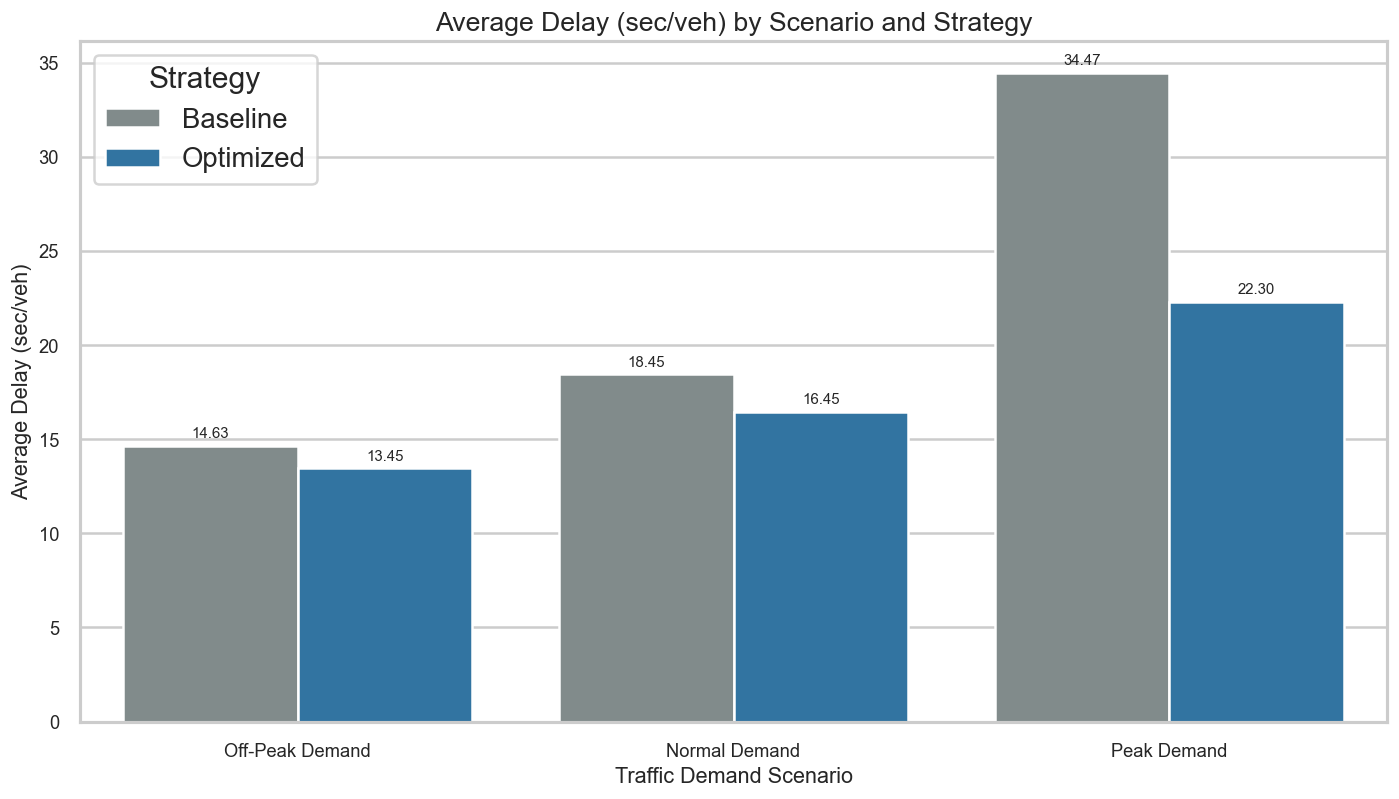

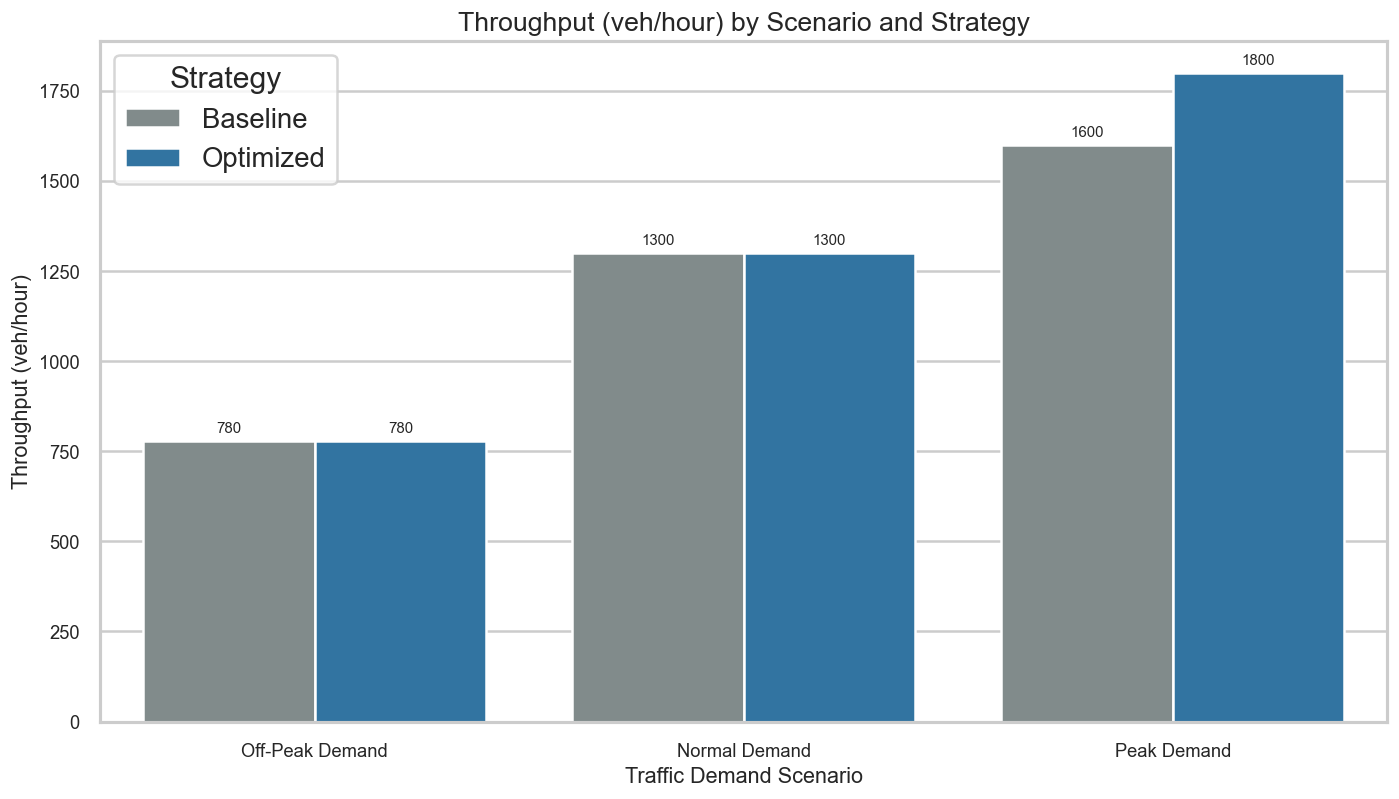


            Throughput increases only when traffic demand approaches the effective capacity of the intersection. Under the **Off-Peak Demand** and **Normal Demand** scenarios, both strategies operate below capacity, so timing differences do not materially change the number of vehicles served. Under **Peak Demand**, the optimized timing plan improves capacity utilization and allows more vehicles to pass through the intersection within the same cycle structure.
            

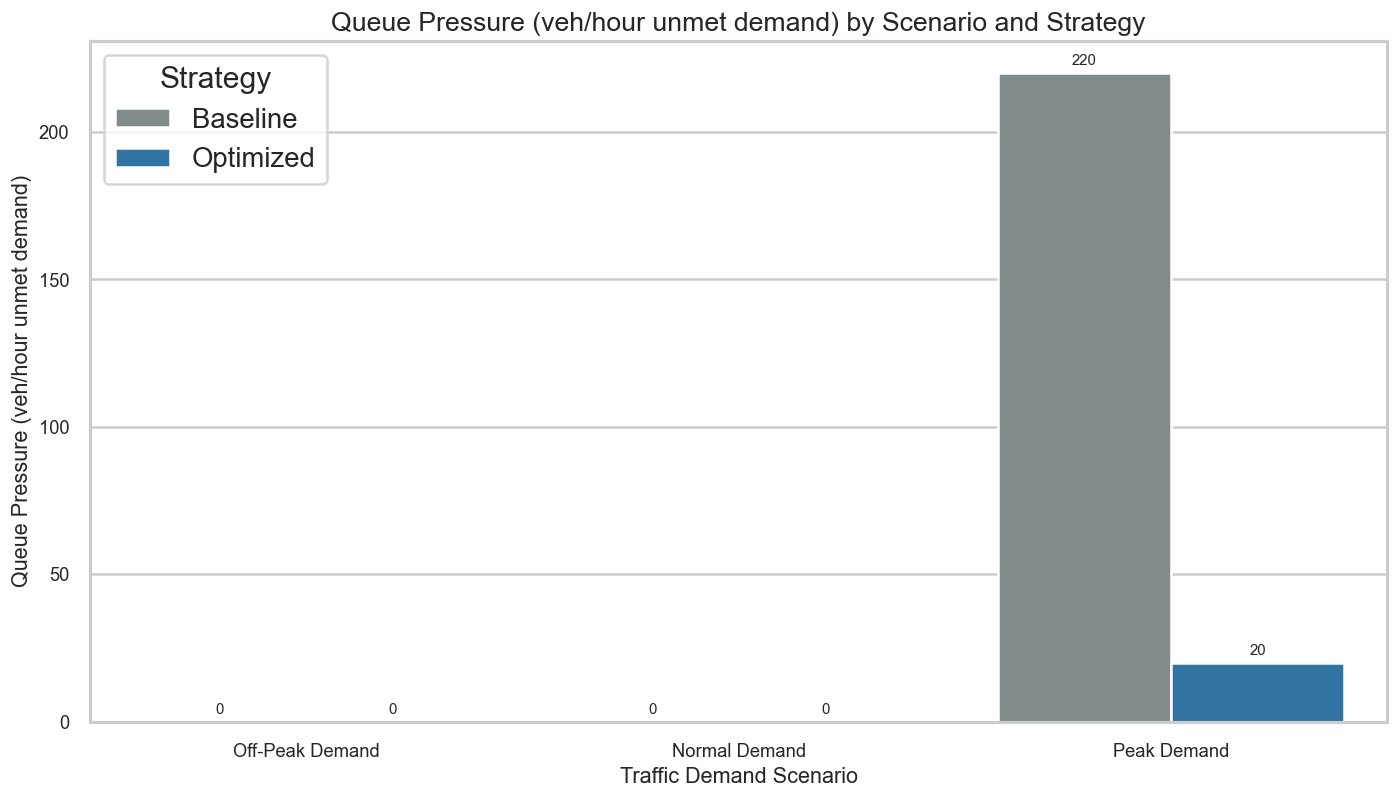


            Queue pressure is defined here as **unmet demand**, or `queue_pressure = demand - capacity`, subject to a lower bound of zero. When demand remains below available capacity, queue pressure is zero and no sustained queue formation is expected. This explains why the **Off-Peak Demand** and **Normal Demand** scenarios show no queue buildup, while the **Peak Demand** scenario exceeds baseline capacity and produces substantial queue pressure that is sharply reduced by the optimized timing strategy.
            

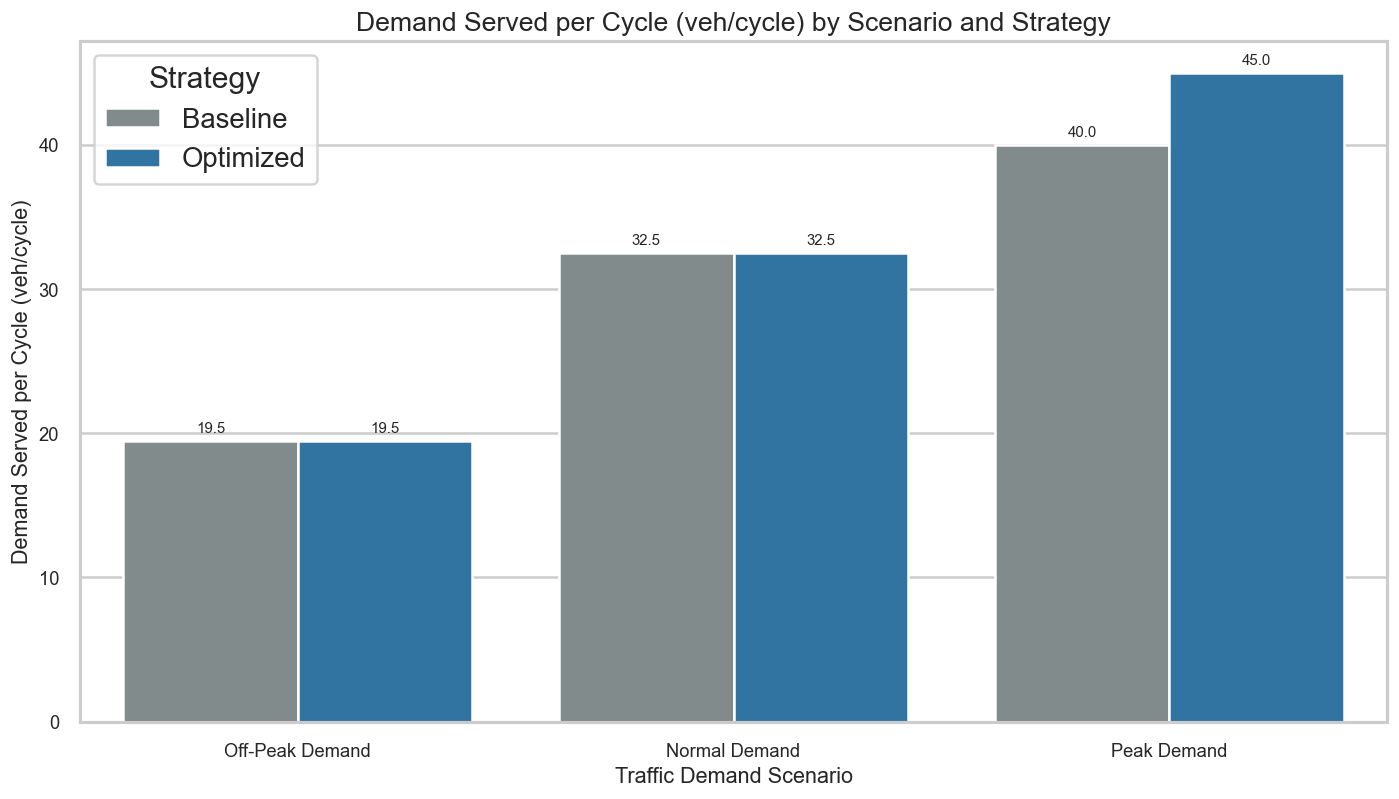

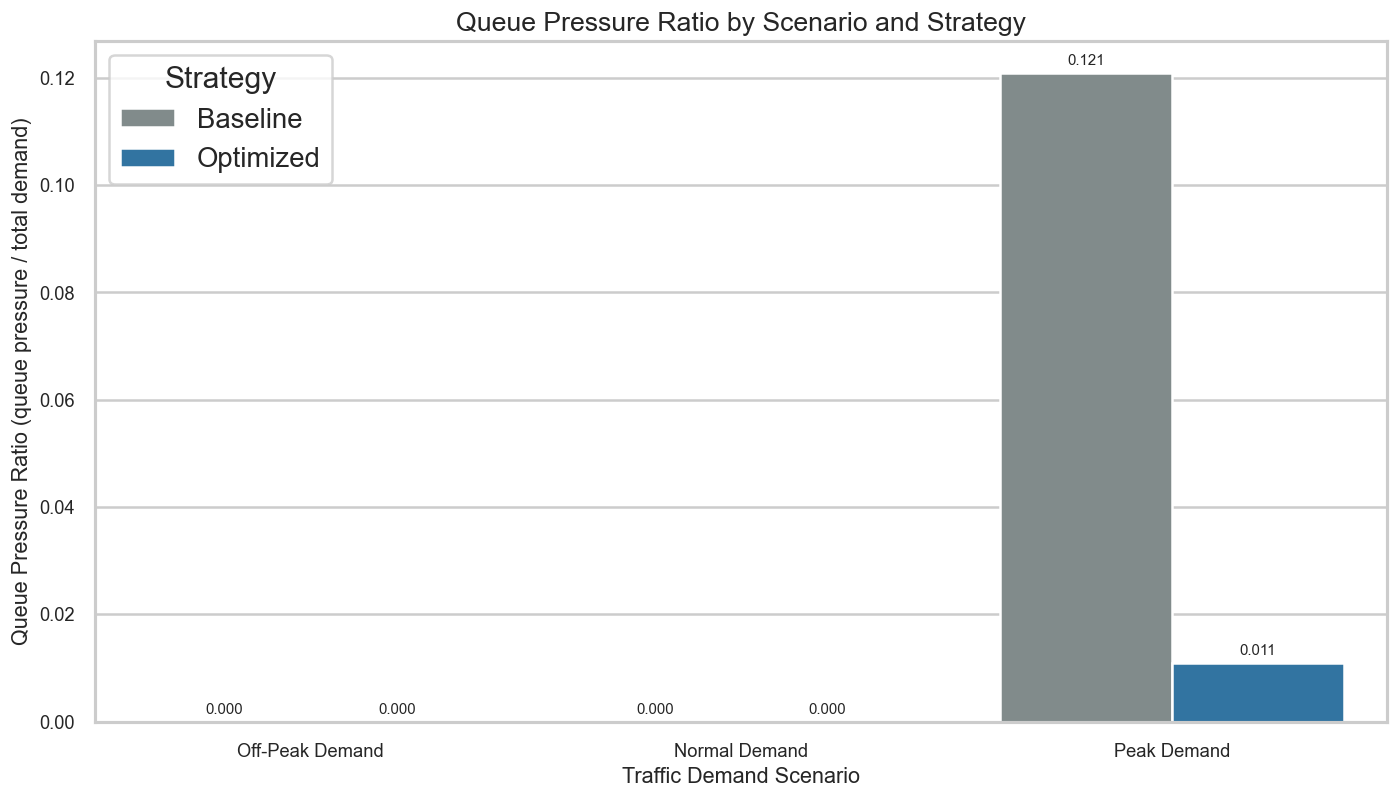

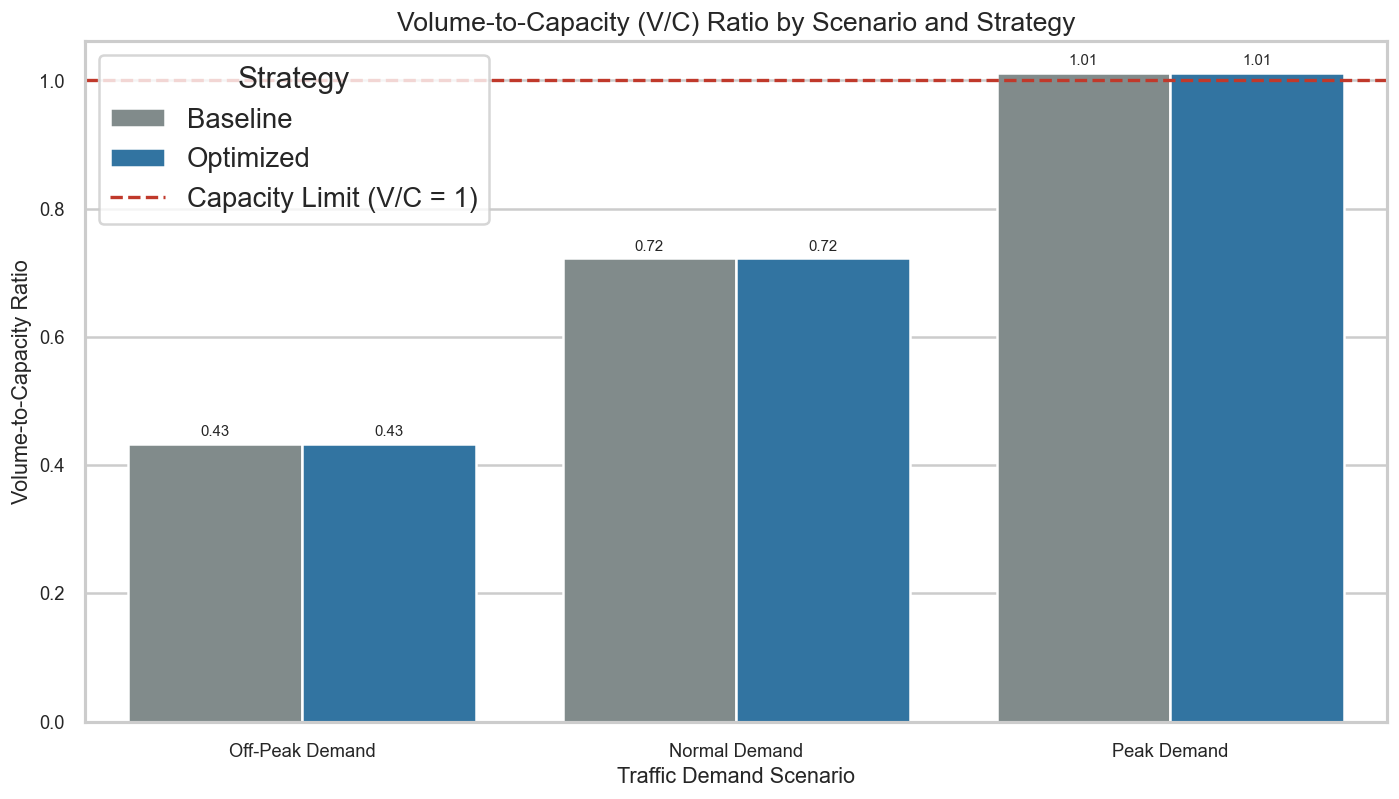


    The **volume-to-capacity (V/C) ratio** is a standard traffic engineering indicator used to evaluate congestion and operational stress at signalized intersections. Values **below 1.0** indicate that the intersection is operating below its estimated capacity, values **near 1.0** suggest operation close to capacity, and values **above 1.0** indicate oversaturation. In this notebook, the V/C ratio complements delay and queue metrics by showing how closely the intersection approaches its effective service limit under different demand scenarios. Because the total cycle length is held constant and all green time remains within the same cycle, the aggregate intersection V/C ratio does not materially change across strategies; the optimized plan improves performance primarily by **redistributing capacity between phases**, not by increasing total system capacity.
    

,scenario,delay_reduction_percent,throughput_increase_percent,queue_pressure_reduction_percent
0,Off-Peak Demand,8.07,0.00,NaN
1,Normal Demand,10.86,0.00,NaN
2,Peak Demand,35.29,12.50,90.91


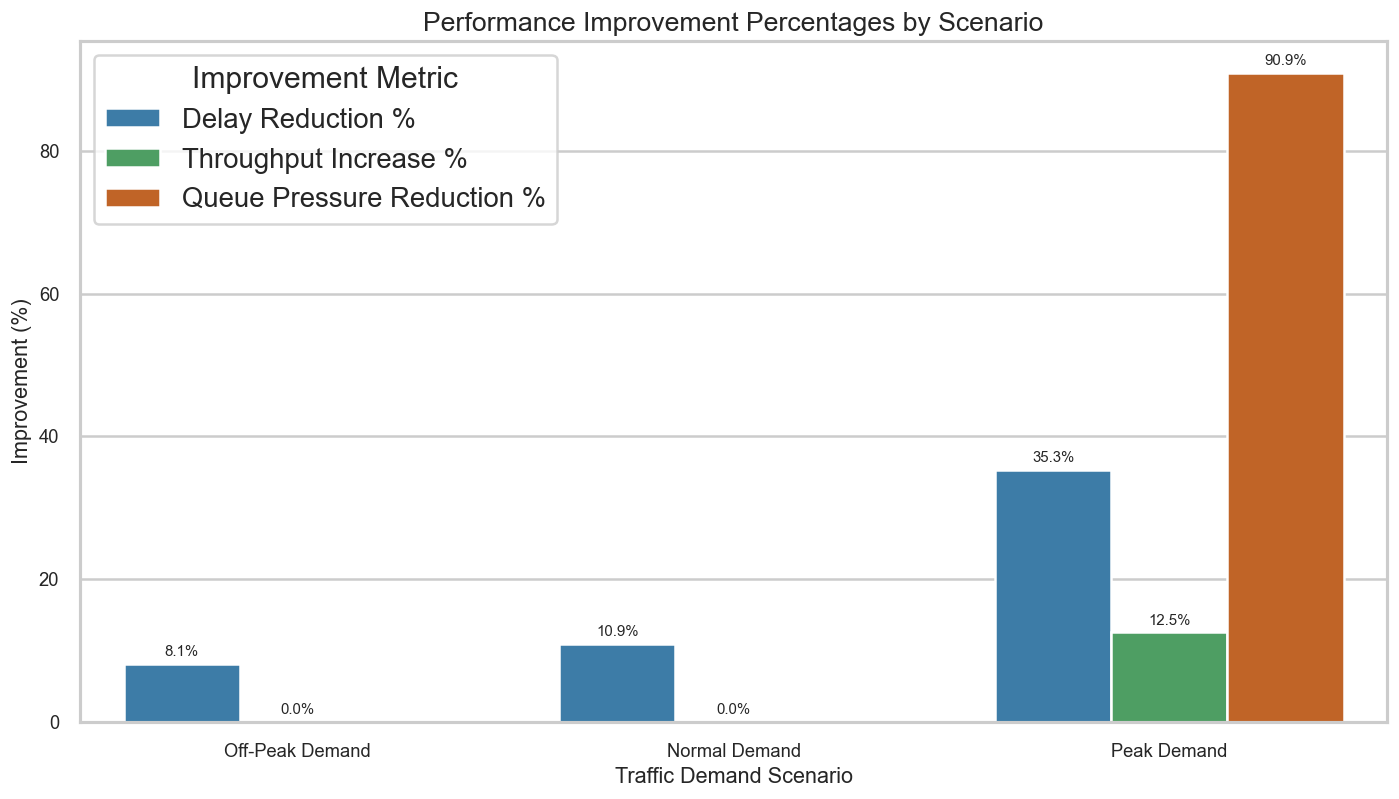

,scenario,metric,baseline_metric,optimized_metric,absolute_difference,percentage_improvement
0,Off-Peak Demand,delay,14.63,13.45,1.18,8.07
1,Off-Peak Demand,throughput,780.00,780.00,0.00,0.00
2,Off-Peak Demand,queue_pressure,0.00,0.00,0.00,0.00
3,Off-Peak Demand,demand_served_per_cycle,19.50,19.50,0.00,0.00
4,Normal Demand,delay,18.45,16.45,2.00,10.86
5,Normal Demand,throughput,"1,300.00","1,300.00",0.00,0.00
6,Normal Demand,queue_pressure,0.00,0.00,0.00,0.00
7,Normal Demand,demand_served_per_cycle,32.50,32.50,0.00,0.00
8,Peak Demand,delay,34.47,22.30,12.16,35.29
9,Peak Demand,throughput,"1,600.00","1,800.00",200.00,12.50


Saved simulation summary to: data/processed/intersection_simulation_summary.csv
Saved enhanced simulation results to: data/processed/intersection_simulation_results_enhanced.csv


In [13]:
metric_specs = [
    ("delay", "Average Delay (sec/veh)", "{:.2f}"),
    ("throughput", "Throughput (veh/hour)", "{:.0f}"),
    ("queue_pressure", "Queue Pressure (veh/hour unmet demand)", "{:.0f}"),
    ("demand_served_per_cycle", "Demand Served per Cycle (veh/cycle)", "{:.1f}"),
]

palette = {"Baseline": "#7f8c8d", "Optimized": "#1f77b4"}
improvement_palette = {
    "Delay Reduction %": "#2c7fb8",
    "Throughput Increase %": "#41ab5d",
    "Queue Pressure Reduction %": "#d95f0e",
}

results_df["total_capacity"] = results_df["capacity_phase1"] + results_df["capacity_phase2"]
results_df["vc_ratio"] = results_df["total_demand"] / results_df["total_capacity"]


def add_bar_labels(ax, fmt="{:.1f}", suffix=""):
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            if np.isnan(height):
                labels.append("")
            else:
                labels.append(f"{fmt.format(height)}{suffix}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)


for metric, label, fmt in metric_specs:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(
        data=results_df,
        x="scenario",
        y=metric,
        hue="strategy",
        palette=palette,
        ax=ax,
    )
    ax.set_title(f"{label} by Scenario and Strategy")
    ax.set_xlabel("Traffic Demand Scenario")
    ax.set_ylabel(label)
    add_bar_labels(ax, fmt=fmt)
    ax.legend(title="Strategy", frameon=True)
    plt.tight_layout()
    plt.show()

    if metric == "throughput":
        display(Markdown(
            """
            Throughput increases only when traffic demand approaches the effective capacity of the intersection. Under the **Off-Peak Demand** and **Normal Demand** scenarios, both strategies operate below capacity, so timing differences do not materially change the number of vehicles served. Under **Peak Demand**, the optimized timing plan improves capacity utilization and allows more vehicles to pass through the intersection within the same cycle structure.
            """
        ))

    if metric == "queue_pressure":
        display(Markdown(
            """
            Queue pressure is defined here as **unmet demand**, or `queue_pressure = demand - capacity`, subject to a lower bound of zero. When demand remains below available capacity, queue pressure is zero and no sustained queue formation is expected. This explains why the **Off-Peak Demand** and **Normal Demand** scenarios show no queue buildup, while the **Peak Demand** scenario exceeds baseline capacity and produces substantial queue pressure that is sharply reduced by the optimized timing strategy.
            """
        ))

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=results_df,
    x="scenario",
    y="queue_pressure_ratio",
    hue="strategy",
    palette=palette,
    ax=ax,
)
ax.set_title("Queue Pressure Ratio by Scenario and Strategy")
ax.set_xlabel("Traffic Demand Scenario")
ax.set_ylabel("Queue Pressure Ratio (queue pressure / total demand)")
add_bar_labels(ax, fmt="{:.3f}")
ax.legend(title="Strategy", frameon=True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=results_df,
    x="scenario",
    y="vc_ratio",
    hue="strategy",
    palette=palette,
    ax=ax,
)
ax.axhline(1.0, color="#c0392b", linestyle="--", linewidth=2, label="Capacity Limit (V/C = 1)")
ax.set_title("Volume-to-Capacity (V/C) Ratio by Scenario and Strategy")
ax.set_xlabel("Traffic Demand Scenario")
ax.set_ylabel("Volume-to-Capacity Ratio")
add_bar_labels(ax, fmt="{:.2f}")
ax.legend(title="Strategy", frameon=True)
plt.tight_layout()
plt.show()

display(Markdown(
    """
    The **volume-to-capacity (V/C) ratio** is a standard traffic engineering indicator used to evaluate congestion and operational stress at signalized intersections. Values **below 1.0** indicate that the intersection is operating below its estimated capacity, values **near 1.0** suggest operation close to capacity, and values **above 1.0** indicate oversaturation. In this notebook, the V/C ratio complements delay and queue metrics by showing how closely the intersection approaches its effective service limit under different demand scenarios. Because the total cycle length is held constant and all green time remains within the same cycle, the aggregate intersection V/C ratio does not materially change across strategies; the optimized plan improves performance primarily by **redistributing capacity between phases**, not by increasing total system capacity.
    """
))

improvement_directions = {
    "delay": "lower",
    "throughput": "higher",
    "queue_pressure": "lower",
    "demand_served_per_cycle": "higher",
}

summary_rows = []
for scenario_name in scenario_df["scenario"]:
    baseline_row = results_df.loc[
        (results_df["scenario"] == scenario_name) & (results_df["strategy"] == "Baseline")
    ].iloc[0]
    optimized_row = results_df.loc[
        (results_df["scenario"] == scenario_name) & (results_df["strategy"] == "Optimized")
    ].iloc[0]

    for metric, _, _ in metric_specs:
        baseline_value = baseline_row[metric]
        optimized_value = optimized_row[metric]

        if improvement_directions[metric] == "higher":
            absolute_difference = optimized_value - baseline_value
        else:
            absolute_difference = baseline_value - optimized_value

        percentage_improvement = 0 if baseline_value == 0 else (absolute_difference / baseline_value) * 100

        summary_rows.append(
            {
                "scenario": scenario_name,
                "metric": metric,
                "baseline_metric": baseline_value,
                "optimized_metric": optimized_value,
                "absolute_difference": absolute_difference,
                "percentage_improvement": percentage_improvement,
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df["scenario"] = pd.Categorical(summary_df["scenario"], categories=scenario_order, ordered=True)
summary_df["metric"] = pd.Categorical(
    summary_df["metric"],
    categories=[metric for metric, _, _ in metric_specs],
    ordered=True,
)
summary_df = summary_df.sort_values(["scenario", "metric"]).reset_index(drop=True)
summary_df.to_csv(summary_output_path, index=False)

baseline_view = (
    results_df.loc[
        results_df["strategy"] == "Baseline",
        ["scenario", "delay", "throughput", "queue_pressure", "vc_ratio", "queue_pressure_ratio"],
    ]
    .rename(
        columns={
            "delay": "delay_baseline",
            "throughput": "throughput_baseline",
            "queue_pressure": "queue_baseline",
            "vc_ratio": "vc_ratio_baseline",
            "queue_pressure_ratio": "queue_pressure_ratio_baseline",
        }
    )
)
optimized_view = (
    results_df.loc[
        results_df["strategy"] == "Optimized",
        ["scenario", "delay", "throughput", "queue_pressure", "vc_ratio", "queue_pressure_ratio"],
    ]
    .rename(
        columns={
            "delay": "delay_optimized",
            "throughput": "throughput_optimized",
            "queue_pressure": "queue_optimized",
            "vc_ratio": "vc_ratio_optimized",
            "queue_pressure_ratio": "queue_pressure_ratio_optimized",
        }
    )
)

performance_improvements = baseline_view.merge(optimized_view, on="scenario")
performance_improvements["delay_reduction_percent"] = (
    (performance_improvements["delay_baseline"] - performance_improvements["delay_optimized"])
    / performance_improvements["delay_baseline"]
) * 100
performance_improvements["throughput_increase_percent"] = (
    (performance_improvements["throughput_optimized"] - performance_improvements["throughput_baseline"])
    / performance_improvements["throughput_baseline"]
) * 100
performance_improvements["queue_pressure_reduction_percent"] = np.where(
    performance_improvements["queue_baseline"] > 0,
    (
        (performance_improvements["queue_baseline"] - performance_improvements["queue_optimized"])
        / performance_improvements["queue_baseline"]
    ) * 100,
    np.nan,
)

display_columns = [
    "scenario",
    "delay_reduction_percent",
    "throughput_increase_percent",
    "queue_pressure_reduction_percent",
]
display(performance_improvements[display_columns].round(2))

improvement_plot_df = performance_improvements[display_columns].melt(
    id_vars="scenario",
    var_name="improvement_metric",
    value_name="percentage",
)

improvement_label_map = {
    "delay_reduction_percent": "Delay Reduction %",
    "throughput_increase_percent": "Throughput Increase %",
    "queue_pressure_reduction_percent": "Queue Pressure Reduction %",
}
improvement_plot_df["improvement_metric"] = improvement_plot_df["improvement_metric"].map(improvement_label_map)
improvement_plot_df = improvement_plot_df.dropna(subset=["percentage"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=improvement_plot_df,
    x="scenario",
    y="percentage",
    hue="improvement_metric",
    palette=improvement_palette,
    ax=ax,
)
ax.set_title("Performance Improvement Percentages by Scenario")
ax.set_xlabel("Traffic Demand Scenario")
ax.set_ylabel("Improvement (%)")
add_bar_labels(ax, fmt="{:.1f}", suffix="%")
ax.legend(title="Improvement Metric", frameon=True)
plt.tight_layout()
plt.show()

enhanced_results_df = results_df.merge(
    performance_improvements[
        [
            "scenario",
            "delay_reduction_percent",
            "throughput_increase_percent",
            "queue_pressure_reduction_percent",
            "vc_ratio_baseline",
            "vc_ratio_optimized",
            "queue_pressure_ratio_baseline",
            "queue_pressure_ratio_optimized",
        ]
    ],
    on="scenario",
    how="left",
)
enhanced_results_df.to_csv(enhanced_results_output_path, index=False)

display(summary_df.round(2))
print(f"Saved simulation summary to: {summary_output_path.relative_to(repo_root)}")
print(f"Saved enhanced simulation results to: {enhanced_results_output_path.relative_to(repo_root)}")


The percentage-based improvement results help clarify how the operational value of signal optimization changes with demand intensity. In the **Off-Peak Demand** scenario, optimization produces only limited benefit because the baseline plan already serves the full demand without queue formation. As demand increases, the comparative gains become more pronounced, especially in terms of delay reduction and service balance across phases.

The **Peak Demand** scenario shows the strongest improvements, including the largest reductions in delay and queue pressure. This pattern is consistent with traffic engineering expectations: adaptive or demand-responsive signal timing is typically most valuable when intersections operate under congested conditions and green time must be allocated more carefully across competing movements.


## 8. Findings and Scenario Interpretation

The final analytical step is to translate the simulation outputs into concise findings. The language below is intentionally careful: the results indicate comparative performance within the notebook's simplified assumptions rather than calibrated field outcomes.


In [14]:
comparison_wide = (
    results_df.pivot(index="scenario", columns="strategy", values=["delay", "throughput", "queue_pressure", "demand_served_per_cycle", "vc_ratio"])
    .sort_index()
)

delay_reduction_by_scenario = (
    results_df.loc[results_df["strategy"] == "Baseline", ["scenario", "delay"]]
    .merge(
        results_df.loc[results_df["strategy"] == "Optimized", ["scenario", "delay"]],
        on="scenario",
        suffixes=("_baseline", "_optimized"),
    )
)
delay_reduction_by_scenario["delay_reduction"] = (
    delay_reduction_by_scenario["delay_baseline"] - delay_reduction_by_scenario["delay_optimized"]
)

highest_delay_row = results_df.loc[results_df["delay"].idxmax()]
best_benefit_row = delay_reduction_by_scenario.loc[delay_reduction_by_scenario["delay_reduction"].idxmax()]

peak_baseline = results_df.query("scenario == 'Peak Demand' and strategy == 'Baseline'").iloc[0]
peak_optimized = results_df.query("scenario == 'Peak Demand' and strategy == 'Optimized'").iloc[0]

findings_md = f"""
**Interpretive findings**

- The **highest estimated delay** occurred in the **{highest_delay_row['scenario']}** scenario under the **{highest_delay_row['strategy']}** strategy, with an average delay proxy of **{highest_delay_row['delay']:.2f} sec/veh**.
- The **largest optimization benefit** was observed in **{best_benefit_row['scenario']}**, where the optimized timing strategy reduced average delay by **{best_benefit_row['delay_reduction']:.2f} sec/veh** relative to the baseline plan.
- Under **Peak Demand**, optimization increased throughput from **{peak_baseline['throughput']:.0f}** to **{peak_optimized['throughput']:.0f} veh/hour** and reduced queue pressure from **{peak_baseline['queue_pressure']:.0f}** to **{peak_optimized['queue_pressure']:.0f} veh/hour**. The aggregate V/C ratio remained approximately **{peak_baseline['vc_ratio']:.2f}** under both strategies because total cycle length and total effective capacity were held constant.
- In the lighter **Off-Peak Demand** and **Normal Demand** scenarios, both strategies served the full simulated demand. In those conditions, the main benefit of the optimized strategy was a moderate delay reduction caused by better alignment between green allocation and directional demand share.
- Overall, the simulation suggests that **demand-responsive timing is most valuable when the intersection approaches or exceeds baseline capacity**, which is consistent with the capstone expectation that optimization should matter most under stronger congestion pressure.
"""

display(Markdown(findings_md))



**Interpretive findings**

- The **highest estimated delay** occurred in the **Peak Demand** scenario under the **Baseline** strategy, with an average delay proxy of **34.47 sec/veh**.
- The **largest optimization benefit** was observed in **Peak Demand**, where the optimized timing strategy reduced average delay by **12.16 sec/veh** relative to the baseline plan.
- Under **Peak Demand**, optimization increased throughput from **1600** to **1800 veh/hour** and reduced queue pressure from **220** to **20 veh/hour**. The aggregate V/C ratio remained approximately **1.01** under both strategies because total cycle length and total effective capacity were held constant.
- In the lighter **Off-Peak Demand** and **Normal Demand** scenarios, both strategies served the full simulated demand. In those conditions, the main benefit of the optimized strategy was a moderate delay reduction caused by better alignment between green allocation and directional demand share.
- Overall, the simulation suggests that **demand-responsive timing is most valuable when the intersection approaches or exceeds baseline capacity**, which is consistent with the capstone expectation that optimization should matter most under stronger congestion pressure.


### Traffic Engineering Interpretation

Optimization provides limited benefit under low demand conditions because the intersection operates below its effective capacity and both strategies are able to serve the full arriving demand. As traffic demand moves closer to the available capacity, the operational value of signal timing adjustment becomes more pronounced because green time allocation begins to influence both service efficiency and congestion buildup.

The **Peak Demand** scenario therefore shows the strongest improvements in delay, throughput, and queue pressure. This result is consistent with established traffic signal control theory: adaptive timing changes are most valuable when an intersection approaches or exceeds capacity and the allocation of green time directly affects oversaturation risk, queue formation, and the number of vehicles served.


### Traffic Engineering Interpretation

Optimization provides limited benefit under low demand conditions because the intersection operates below its effective capacity and both strategies are able to serve the full arriving demand. As traffic demand moves closer to the available capacity, the operational value of signal timing adjustment becomes more pronounced because green time allocation begins to influence both service efficiency and congestion buildup.

The **Peak Demand** scenario therefore shows the strongest improvements in delay, throughput, and queue pressure. This result is consistent with established traffic signal control theory: adaptive timing changes are most valuable when an intersection approaches or exceeds capacity and the allocation of green time directly affects oversaturation risk, queue formation, and the number of vehicles served.


## 9. Conclusion and Next Steps

This notebook showed that scenario-based intersection simulation can be used to evaluate traffic signal timing strategies in a transparent and reproducible way. Within the simplified analytical framework, higher demand levels produced materially worse delay and queue pressure under the baseline fixed-time plan, while the optimized demand-responsive strategy delivered the strongest comparative benefit when demand was heaviest.

These findings should be interpreted as comparative evidence rather than field-calibrated operational forecasts. Even so, the notebook provides an important bridge between earlier forecasting and optimization formulation work: it supplies a reusable simulation environment for later impact evaluation, sensitivity analysis, and eventual integration with more formal optimization or external simulation platforms.
